# 11 — IRB EAD and Effective Maturity

## Measuring exposure and time in IRB

PD and LGD are available. This notebook estimates IRB EAD for funded and revolving facilities and applies the effective-maturity bounds used by applicable non-retail risk functions.

IRB EAD scales the capital requirement into rupees. Effective maturity adjusts corporate, sovereign and bank capital; the selected retail functions do not use the same maturity adjustment.

### The two facility measures built here

| Term | Simple meaning |
|---|---|
| Own CCF estimate | a synthetic facility-level conversion assumption used where own EAD estimation is represented |
| Effective maturity | remaining contractual economic maturity used in the IRB function |
| Maturity floor | one year for the ordinary scope represented here |
| Maturity cap | five years for the ordinary scope represented here |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from basel_credit_risk.config import load_all_config
from basel_credit_risk.notebook_support import display, ensure_outputs

CRORE = 10_000_000
COLORS = ["#0B3A53", "#1F77B4", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
configs = load_all_config(ROOT / "config")
ensure_outputs(ROOT)
loans = pd.read_csv(ROOT / "data/processed/current_calculated.csv.gz", low_memory=False)
print(f"Portfolio represented: {len(loans):,} synthetic exposures")

Portfolio represented: 30,000 synthetic exposures


> Own CCF values are synthetic. A bank would compare drawn amounts before default with EAD at default, estimate realised conversion by facility type and apply representative long-run and downturn treatment where material.

## Standardised Approach CCF versus IRB CCF

Foundation-parameter rows retain supervisory CCF treatment. Eligible own-estimate and retail rows use the project's explicit synthetic own CCF assumptions. The source field keeps these routes separate.

In [2]:
ccf_comparison = loans.groupby(["commitment_type", "irb_ccf_source"], as_index=False).agg(
    loans=("exposure_id", "count"),
    average_sa_ccf=("ccf", "mean"),
    average_irb_ccf=("irb_ccf", "mean"),
    undrawn=("undrawn_amount", "sum"),
)
ccf_comparison["undrawn"] /= CRORE
display(ccf_comparison.rename(columns={"undrawn": "Undrawn (INR crore)"}))

,commitment_type,irb_ccf_source,loans,average_sa_ccf,average_irb_ccf,Undrawn (INR crore)
0,no_commitment,SUPERVISORY_CCF,16350,0.000000,0.000000,0.000000
1,other_commitment,SUPERVISORY_CCF,2070,0.400000,0.400000,144368.057224
2,other_commitment,SYNTHETIC_OWN_CCF_ESTIMATE,7326,0.400000,0.550000,203725.088951
3,unconditionally_cancellable,SYNTHETIC_OWN_CCF_ESTIMATE,4254,0.100000,0.150000,38.042582


IRB EAD remains `funded exposure + IRB CCF × undrawn`. The difference is the parameter source, not the arithmetic. A higher own CCF assumption increases IRB EAD and therefore IRB RWA.

## Maturity floor and cap

For own-estimate non-retail facilities, contractual maturity is a conservative proxy for cash-flow-weighted effective maturity, bounded between one and five years. Foundation facilities instead use 2.5 years. These examples show how a contractual-maturity proxy behaves within the bounds.

In [3]:
maturity_examples = pd.DataFrame({
    "Contractual maturity": [0.5, 1, 2, 3, 4, 5, 6, 7],
})
maturity_examples["Effective maturity"] = maturity_examples["Contractual maturity"].clip(1, 5)
display(maturity_examples)

,Contractual maturity,Effective maturity
0,0.500000,1.000000
1,1.000000,1.000000
2,2.000000,2.000000
3,3.000000,3.000000
4,4.000000,4.000000
5,5.000000,5.000000
6,6.000000,5.000000
7,7.000000,5.000000


The line below makes both limits visible. Below one year, the ordinary floor lifts M to one. Between one and five years, M follows the contract. Beyond five years, the cap holds M at five.

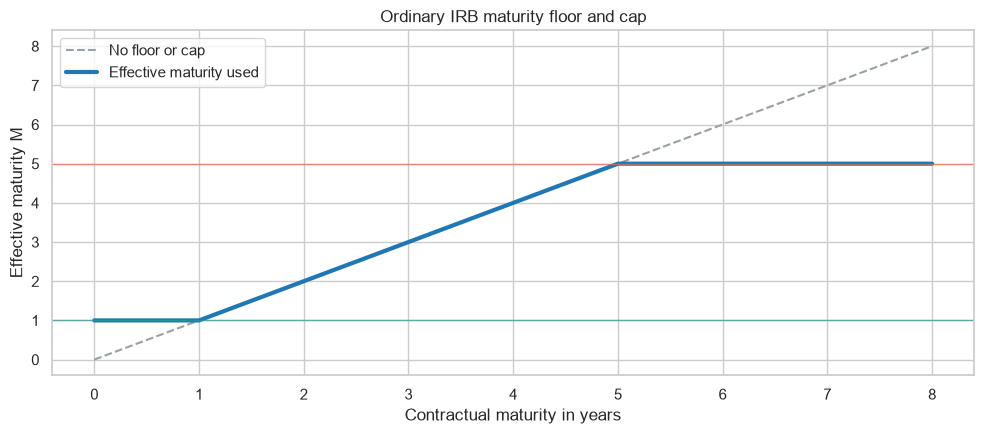

In [4]:
contractual_years = np.linspace(0, 8, 81)
effective_years = np.clip(contractual_years, 1, 5)

plt.figure(figsize=(10, 4.5))
plt.plot(contractual_years, contractual_years, linestyle="--", color="#9AA0A6", label="No floor or cap")
plt.plot(contractual_years, effective_years, linewidth=3, color=COLORS[1], label="Effective maturity used")
plt.axhline(1, color=COLORS[2], linewidth=1, alpha=0.7)
plt.axhline(5, color=COLORS[5], linewidth=1, alpha=0.7)
plt.xlabel("Contractual maturity in years")
plt.ylabel("Effective maturity M")
plt.title("Ordinary IRB maturity floor and cap")
plt.legend()
plt.tight_layout()
plt.show()

The flat sections are important for interpretation: a six-year and an eight-year loan both enter this ordinary calculation with M equal to five, while a six-month loan enters with M equal to one.

A six- or seven-year facility therefore enters the ordinary corporate maturity adjustment with M equal to five. Retail risk functions retain the maturity field for traceability but their maturity adjustment is one.

## Loan-level EAD and maturity examples

The table shows one row for each product and parameter source, including the funded amount, undrawn amount, IRB CCF, resulting EAD and capped maturity.

Own-estimate non-sovereign EAD cannot fall below funded exposure plus 50% of the SA-converted undrawn amount. The table shows the estimate, floor and final EAD separately. Own CCFs apply only to eligible revolving commitments; other commitments use supervisory CCFs.

In [5]:
irb_ead_examples = (
    loans.sort_values(["product_type", "irb_parameter_source", "exposure_id"])
    .groupby(["product_type", "irb_parameter_source"], as_index=False)
    .first()[["exposure_id", "product_type", "irb_parameter_source", "funded_exposure", "undrawn_amount", "irb_ccf", "ead_irb_before_floor", "ead_irb_floor", "ead_irb", "maturity_source", "maturity_input", "m_effective", "maturity_cap_applied"]]
)
money_columns = ["funded_exposure", "undrawn_amount", "ead_irb_before_floor", "ead_irb_floor", "ead_irb"]
irb_ead_examples[money_columns] /= CRORE
display(irb_ead_examples.rename(columns={column: f"{column} (INR crore)" for column in money_columns}))

,exposure_id,product_type,irb_parameter_source,funded_exposure (INR crore),undrawn_amount (INR crore),irb_ccf,ead_irb_before_floor (INR crore),ead_irb_floor (INR crore),ead_irb (INR crore),maturity_source,maturity_input,m_effective,maturity_cap_applied
0,EXP-0027601,bank_loan,FOUNDATION_SUPERVISORY_PARAMETERS,25.645528,24.290341,0.400000,35.361664,30.503596,35.361664,FOUNDATION_2_5_YEARS,4.113320,2.500000,False
1,EXP-0009616,corporate_revolver,FOUNDATION_SUPERVISORY_PARAMETERS,95.754333,15.464342,0.400000,101.940070,98.847202,101.940070,FOUNDATION_2_5_YEARS,10.090998,2.500000,False
2,EXP-0009601,corporate_revolver,OWN_ESTIMATE_PARAMETERS,236.254890,247.970913,0.550000,372.638892,285.849072,372.638892,CONTRACTUAL_CONSERVATIVE_PROXY,4.670098,4.670098,False
3,EXP-0021601,credit_card,RETAIL_IRB_OWN_ESTIMATES,0.001779,0.002925,0.150000,0.002218,0.001926,0.002218,CONTRACTUAL_CONSERVATIVE_PROXY,0.710200,1.000000,False
4,EXP-0000001,mortgage,RETAIL_IRB_OWN_ESTIMATES,0.209763,0.000000,0.000000,0.209763,0.209763,0.209763,CONTRACTUAL_CONSERVATIVE_PROXY,2.006028,2.006028,False
5,EXP-0029401,other,OWN_ESTIMATE_PARAMETERS,0.528723,0.217900,0.550000,0.648568,0.572303,0.648568,CONTRACTUAL_CONSERVATIVE_PROXY,0.436807,1.000000,False
6,EXP-0015601,personal_loan,RETAIL_IRB_OWN_ESTIMATES,0.088284,0.000000,0.000000,0.088284,0.088284,0.088284,CONTRACTUAL_CONSERVATIVE_PROXY,3.052586,3.052586,False
7,EXP-0012601,sme_revolver,OWN_ESTIMATE_PARAMETERS,5.196715,10.275412,0.550000,10.848192,7.251798,10.848192,CONTRACTUAL_CONSERVATIVE_PROXY,0.991197,1.000000,False
8,EXP-0028651,sovereign_bond,OWN_ESTIMATE_PARAMETERS,43.171251,0.000000,0.000000,43.171251,43.171251,43.171251,CONTRACTUAL_CONSERVATIVE_PROXY,0.407215,1.000000,False


The table shows the facility-dependent exposure and maturity inputs. Each loan now has PD, downturn LGD, IRB EAD and effective maturity before the correlation and Vasicek capital function is applied.